# 05 — Binary home-win models

This notebook studies a second prediction target:

$$
Z_i=\mathbb{1}(X_i>Y_i),
$$

where $X_i$ and $Y_i$ are the home and away goals in match $i$. Therefore:

- $Z_i=1$ means a **home win**;
- $Z_i=0$ means a **home non-win**, combining a draw and an away win.

The binary task is not obtained by merely deleting the draw class from the 1X2 analysis. Feature relevance, class balance, tuned hyperparameters, and probability calibration can all differ. The direct binary classifiers therefore receive their own fold-safe feature selection and tuning.

The final comparison also includes the locked 1X2 probability aggregated as $P(\text{home win})$, the Poisson probability $P(X>Y)$, and the training-majority baseline. All decisions use only the 2021/22–2023/24 development period. The 2024/25 outcomes remain sealed for Notebook 06.

## 1. Data and method sources

The match-level analytical table was prepared in Notebooks 01 and 02. Its sources are:

- [Understat](https://understat.com/) for fixtures, results, expected goals, expected points, PPDA, and deep completions;
- [ClubElo](http://clubelo.com/) for dated club ratings;
- [SoFIFA](https://sofifa.com/) for dated squad-strength aggregates;
- [Football-Data](https://www.football-data.co.uk/) for archived pre-match odds.

Every engineered predictor is shifted so that it contains only information available before the predicted match. Market probabilities are based on margin-normalised archived odds and belong only to the market branch.

The shadow-feature procedure follows the logic of Kursa and Rudnicki (2010), [*Feature Selection with the Boruta Package*](https://doi.org/10.18637/jss.v036.i11). Recursive feature elimination follows Guyon et al. (2002), [*Gene Selection for Cancer Classification using Support Vector Machines*](https://doi.org/10.1023/A:1012487302797). The implementation uses a transparent shadow benchmark and logistic RFE rather than treating either article as an unchanged software recipe.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"))
logical_cores = max(1, os.cpu_count() or 1)
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, min(8, logical_cores - 1)))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification import (
    BINARY_MODEL_LABELS,
    MODEL_GRIDS,
    MODEL_LABELS,
    make_classifier,
    make_preprocessor,
    ordered_probabilities,
)
from src.config import DEVELOPMENT_SEASONS, FINAL_TEST_SEASON, PROCESSED_DATA_DIR, RANDOM_STATE
from src.evaluation import evaluate_binary
from src.feature_engineering import get_feature_sets
from src.feature_selection import (
    initial_feature_screen,
    rfe_relevance_ranking,
    shadow_feature_relevance,
    spearman_redundancy_filter,
    summarize_selection_stability,
)
from src.poisson_models import fit_poisson_model, poisson_probabilities
from src.validation import development_folds, summarize_folds, weighted_metric_summary

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 4000)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)

COLOURS = {
    "structural": "#1F4E79",
    "market": "#E9C46A",
    "poisson": "#4E9F6D",
    "aggregate": "#7A5195",
    "baseline": "#9AA6B2",
    "target": "#C44E52",
}
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
    "grid.alpha": 0.22,
})

## 2. Development data and target construction

The target is calculated from final goals, but final goals never enter the predictor matrix. For match $i$,

$$
Z_i =
\begin{cases}
1, & X_i>Y_i,\\
0, & X_i\leq Y_i.
\end{cases}
$$

The inequality in the second line is important: a draw is a home non-win. The positive class is always the home win, so precision and recall below refer to home wins.

In [2]:
features = pd.read_csv(PROCESSED_DATA_DIR / "match_features.csv", parse_dates=["date"])
features = features.sort_values(["date", "league_id", "game_id"]).reset_index(drop=True)
development = features.loc[
    features["season_id"].isin(DEVELOPMENT_SEASONS)
    & features["sample_role"].eq("development")
].copy()

assert development["season_id"].max() < FINAL_TEST_SEASON
assert development["home_win"].isin([0, 1]).all()
assert (
    development["home_win"]
    == (development["home_goals"] > development["away_goals"]).astype(int)
).all()

sample_columns = [
    "date", "league_id", "season_id", "home_team", "away_team",
    "home_goals", "away_goals", "target_1x2", "home_win", "sample_role",
]
display(development[sample_columns].sample(8, random_state=42))

,date,league_id,season_id,home_team,away_team,home_goals,away_goals,target_1x2,home_win,sample_role
2124,2022-09-16,LIGUE_1,2022,Auxerre,Lorient,1,3,A,0,development
4122,2023-10-29,LIGUE_1,2023,Brest,Paris Saint Germain,2,3,A,0,development
2867,2023-02-12,LALIGA,2022,Celta Vigo,Atletico Madrid,0,1,A,0,development
4283,2023-12-02,EPL,2023,Brentford,Luton,3,1,H,1,development
2596,2023-01-02,LIGUE_1,2022,Strasbourg,Troyes,2,3,A,0,development
952,2022-01-10,SERIE_A,2021,Torino,Fiorentina,4,0,H,1,development
3063,2023-03-12,EPL,2022,Newcastle United,Wolverhampton Wanderers,2,1,H,1,development
381,2021-10-16,EPL,2021,Manchester City,Burnley,2,0,H,1,development


The representative rows verify that a home draw and a home defeat both receive `home_win = 0`. Goals are retained in the table for target construction and later Poisson fitting, but the candidate feature sets exclude them.

In [3]:
LEAGUES = {
    "BUNDESLIGA": "Bundesliga",
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "LIGUE_1": "Ligue 1",
    "SERIE_A": "Serie A",
}
SCOPES = [(code, name) for code, name in LEAGUES.items()] + [("POOLED", "Pooled five-league model")]

balance_rows = []
for scope_code, scope_name in SCOPES:
    scope_frame = development if scope_code == "POOLED" else development.loc[development["league_id"].eq(scope_code)]
    balance_rows.append({
        "scope_code": scope_code,
        "scope": scope_name,
        "matches": len(scope_frame),
        "home_wins": int(scope_frame["home_win"].sum()),
        "home_win_rate": scope_frame["home_win"].mean(),
        "home_non_win_rate": 1 - scope_frame["home_win"].mean(),
        "majority_accuracy": max(scope_frame["home_win"].mean(), 1 - scope_frame["home_win"].mean()),
    })

target_balance = pd.DataFrame(balance_rows)
display(
    target_balance.style
    .format({"home_win_rate": "{:.2%}", "home_non_win_rate": "{:.2%}", "majority_accuracy": "{:.2%}"})
    .hide(axis="index")
)

scope_code,scope,matches,home_wins,home_win_rate,home_non_win_rate,majority_accuracy
BUNDESLIGA,Bundesliga,918,422,45.97%,54.03%,54.03%
EPL,Premier League,1140,522,45.79%,54.21%,54.21%
LALIGA,La Liga,1140,514,45.09%,54.91%,54.91%
LIGUE_1,Ligue 1,1066,445,41.74%,58.26%,58.26%
SERIE_A,Serie A,1140,468,41.05%,58.95%,58.95%
POOLED,Pooled five-league model,5404,2371,43.87%,56.13%,56.13%


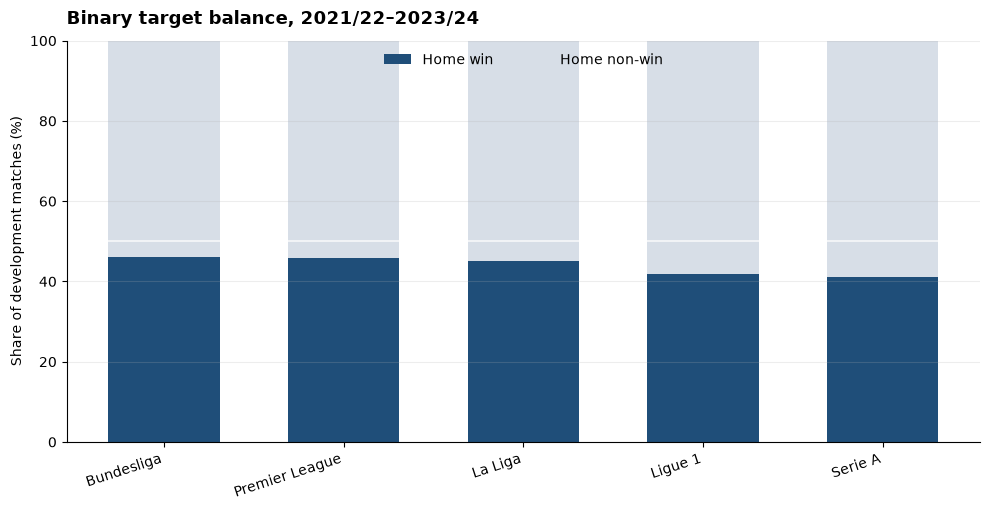

In [4]:
plot_balance = target_balance.loc[target_balance["scope_code"].ne("POOLED")].copy()
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(plot_balance))
ax.bar(x, 100 * plot_balance["home_win_rate"], color=COLOURS["structural"], width=0.62, label="Home win")
ax.bar(x, 100 * plot_balance["home_non_win_rate"], bottom=100 * plot_balance["home_win_rate"], color="#D7DEE7", width=0.62, label="Home non-win")
ax.axhline(50, color="white", linewidth=1.2, alpha=0.8)
ax.set_xticks(x, plot_balance["scope"], rotation=18, ha="right")
ax.set_ylabel("Share of development matches (%)")
ax.set_title("Binary target balance, 2021/22–2023/24", loc="left", pad=12)
ax.legend(frameon=False, ncol=2, loc="upper center")
ax.set_ylim(0, 100)
ax.grid(axis="y")
fig.tight_layout()
plt.show()

Home wins form the minority class in every league, but the imbalance is moderate rather than extreme. Accuracy must therefore be compared with the majority baseline and with balanced accuracy. A model can achieve acceptable overall accuracy while detecting too few home wins, which would be visible through recall and the confusion matrix.

## 3. Chronological validation

The same two expanding development folds are used throughout the project:

1. train on 2021/22, validate on 2022/23, weight 40%;
2. train on 2021/22–2022/23, validate on 2023/24, weight 60%.

Feature screening, imputation, scaling, relevance ranking, model fitting, and probability generation are repeated inside each training fold. No validation-season value is used to select its own features.

In [5]:
fold_rows = []
for scope_code, scope_name in SCOPES:
    scope_frame = development if scope_code == "POOLED" else development.loc[development["league_id"].eq(scope_code)]
    timing = summarize_folds(scope_frame, development_folds(scope_frame))
    timing.insert(0, "scope", scope_name)
    fold_rows.append(timing)

binary_fold_timing = pd.concat(fold_rows, ignore_index=True)
display(
    binary_fold_timing.style
    .format({"weight": "{:.0%}", "last_train_date": "{:%d %b %Y}", "first_validation_date": "{:%d %b %Y}"})
    .hide(axis="index")
)

scope,fold,weight,train_seasons,validation_season,train_matches,validation_matches,last_train_date,first_validation_date
Bundesliga,1,40%,2021,2022,306,306,14 May 2022,05 Aug 2022
Bundesliga,2,60%,"2021, 2022",2023,612,306,27 May 2023,18 Aug 2023
Premier League,1,40%,2021,2022,380,380,22 May 2022,05 Aug 2022
Premier League,2,60%,"2021, 2022",2023,760,380,28 May 2023,11 Aug 2023
La Liga,1,40%,2021,2022,380,380,22 May 2022,12 Aug 2022
La Liga,2,60%,"2021, 2022",2023,760,380,04 Jun 2023,11 Aug 2023
Ligue 1,1,40%,2021,2022,380,380,21 May 2022,05 Aug 2022
Ligue 1,2,60%,"2021, 2022",2023,760,306,03 Jun 2023,12 Aug 2023
Serie A,1,40%,2021,2022,380,380,22 May 2022,13 Aug 2022
Serie A,2,60%,"2021, 2022",2023,760,380,04 Jun 2023,19 Aug 2023


The pooled model has more training observations, but it is not allowed to see a later season than a league-specific model. `league_id` is one-hot encoded for the pooled branch so that league-level differences do not have to be represented only through numerical football features.

## 4. Information branches and candidate variables

Two information cut-offs are retained:

- **structural/day-before:** lagged Understat history, internal Elo, ClubElo, dated SoFIFA, rest, promoted-team indicators, and league context;
- **market/closing-market:** the structural set plus archived margin-normalised home and draw probabilities, overround, and market availability.

The away market probability is not an additional candidate because the three normalised probabilities sum to one. Keeping home and draw probabilities already determines the away probability and avoids exact linear redundancy.

In [6]:
feature_sets = get_feature_sets(development)

CORE_STRUCTURAL = [
    "elo_diff_pre",
    "clubelo_diff",
    "clubelo_available",
    "diff_sofifa_top11_overall",
    "sofifa_available",
    "diff_xg_diff_ewm_span_5",
    "diff_points_mean_last_5",
    "diff_rest_days",
    "home_promoted_or_returning",
    "away_promoted_or_returning",
]
CORE_MARKET = CORE_STRUCTURAL + [
    "market_prob_home",
    "market_prob_draw",
    "market_overround",
    "market_available",
]

BASE_CANDIDATES = {
    "structural": [feature for feature in feature_sets["structural_full"] if feature != "league_id"],
    "market": [feature for feature in feature_sets["market_full"] if feature not in {"league_id", "market_prob_away"}],
}

candidate_overview = pd.DataFrame([
    {
        "branch": branch,
        "separate_league_candidates": len(candidates),
        "mandatory_core": len(CORE_STRUCTURAL if branch == "structural" else CORE_MARKET),
        "pooled_addition": "league_id",
    }
    for branch, candidates in BASE_CANDIDATES.items()
])
display(candidate_overview.style.hide(axis="index"))

branch,separate_league_candidates,mandatory_core,pooled_addition
structural,228,10,league_id
market,232,14,league_id


The mandatory core is fixed by football reasoning before binary performance is observed. It represents team strength, recent performance, squad quality, rest, promoted-team uncertainty, and—only in the market branch—the market's own probability assessment. Mandatory does not mean statistically significant; it means the variable has a defensible role that should not disappear solely because one short training fold ranks a correlated substitute slightly higher.

## 5. Binary feature-selection methodology

Selection is repeated for every league, the pooled scope, both branches, and both folds. The sequence is:

1. **Validity screen.** Identifiers, target variables, current-match goals and xG, and unavailable post-match quantities are absent from the candidate lists by construction.
2. **Quality screen.** A non-mandatory feature is rejected if more than 40% is missing, if it is constant, or if one value occupies at least 99.5% of its observed rows.
3. **Mandatory core.** Available football-informed core variables are retained.
4. **Spearman redundancy control.** For numerical variables $j$ and $k$,

$$
r_{s,jk}=\operatorname{Corr}\bigl(\operatorname{rank}(V_j),\operatorname{rank}(V_k)\bigr).
$$

If $|r_{s,jk}|\geq0.92$, the later non-mandatory variable is rejected. Spearman correlation is used because monotone redundancy need not be linear.
5. **Shadow relevance.** Every real candidate is compared with independently permuted copies. In repetition $b$, feature $j$ records a hit when

$$
I_j^{(b)}>\max_k I_{\widetilde V_k}^{(b)},
$$

where $I$ is random-forest importance and $\widetilde V_k$ is a shadow feature. Six repetitions are used. Hit rates of at least 60% are confirmed; 34%–59% are tentative.
6. **RFE ranking.** Confirmed and tentative candidates enter logistic recursive feature elimination. At each step the weakest coefficient-based variables are removed and the remaining set is re-estimated.
7. **Subset-size validation.** Compact, standard, and full-relevant supplements contain at most 4, 8, and 16 ranked non-mandatory features in addition to the core.
8. **Stability audit.** Selection frequency across the two folds is reported. Stability describes robustness; it is not used as a hidden third validation score.

All missing-value medians, correlations, shadows, and RFE ranks are calculated from the relevant training fold only.

In [7]:
SUBSET_LIMITS = {"compact": 4, "standard": 8, "full_relevant": 16}
LEVEL_ORDER = {"compact": 0, "standard": 1, "full_relevant": 2}


def scope_data(scope_code: str) -> pd.DataFrame:
    if scope_code == "POOLED":
        return development.copy()
    return development.loc[development["league_id"].eq(scope_code)].copy()


def branch_definition(scope_code: str, branch: str) -> tuple[list[str], list[str]]:
    candidates = list(BASE_CANDIDATES[branch])
    mandatory = list(CORE_STRUCTURAL if branch == "structural" else CORE_MARKET)
    if scope_code == "POOLED":
        candidates = ["league_id"] + candidates
        mandatory = ["league_id"] + mandatory
    return candidates, mandatory


def select_training_features(train: pd.DataFrame, scope_code: str, branch: str, target_column: str):
    candidates, mandatory = branch_definition(scope_code, branch)
    screened, screen_audit = initial_feature_screen(
        train, candidates, mandatory, missing_threshold=0.40, dominant_threshold=0.995
    )
    available_mandatory = [feature for feature in mandatory if feature in screened]
    decorrelated, correlation_audit = spearman_redundancy_filter(
        train, screened, available_mandatory, threshold=0.92
    )
    supplement = [feature for feature in decorrelated if feature not in available_mandatory]
    shadow_selected, shadow_audit = shadow_feature_relevance(
        train, train[target_column], supplement, iterations=6, n_estimators=180
    )
    fallback_features = []
    if len(shadow_selected) < 4:
        fallback_features = [
            feature for feature in shadow_audit["feature"]
            if feature not in shadow_selected
        ][: 4 - len(shadow_selected)]
    rfe_pool = list(dict.fromkeys(shadow_selected + fallback_features))
    rfe = rfe_relevance_ranking(train, train[target_column], rfe_pool)
    importance = shadow_audit.set_index("feature")["mean_importance"].to_dict()
    rfe_rank = rfe.set_index("feature")["rfe_rank"].to_dict()
    ranked = sorted(
        rfe_pool,
        key=lambda feature: (int(rfe_rank.get(feature, 10_000)), -importance.get(feature, 0.0), feature),
    )
    feature_lists = {
        level: list(dict.fromkeys(available_mandatory + ranked[: min(limit, len(ranked))]))
        for level, limit in SUBSET_LIMITS.items()
    }
    return {
        "feature_lists": feature_lists,
        "mandatory": available_mandatory,
        "ranked_supplement": ranked,
        "fallback": fallback_features,
        "screen_audit": screen_audit,
        "correlation_audit": correlation_audit,
        "shadow_audit": shadow_audit,
        "rfe_audit": rfe,
    }


def fitted_probabilities(train, validation, columns, model_name, parameters, task="binary"):
    preprocessor = make_preprocessor(columns)
    x_train = preprocessor.fit_transform(train[columns])
    x_validation = preprocessor.transform(validation[columns])
    classifier = make_classifier(model_name, parameters, task=task)
    if task == "multiclass" and model_name == "xgboost":
        labels = np.array(["H", "D", "A"])
        y_train = pd.Categorical(train["target_1x2"], categories=labels).codes
        classifier.fit(x_train, y_train)
        return classifier.predict_proba(x_validation)
    target = train["home_win"] if task == "binary" else train["target_1x2"]
    classifier.fit(x_train, target)
    labels = np.array([0, 1]) if task == "binary" else np.array(["H", "D", "A"])
    probabilities = ordered_probabilities(classifier, x_validation, labels)
    return probabilities[:, 1] if task == "binary" else probabilities


def choose_with_tolerance(summary: pd.DataFrame, groups: list[str], complexity_column: str | None = None):
    rows = []
    for _, group in summary.groupby(groups, sort=True):
        best_accuracy = group["accuracy"].max()
        comparable = group.loc[group["accuracy"].ge(best_accuracy - 0.005)].copy()
        sort_columns = ["log_loss", "brier_score"]
        if complexity_column:
            sort_columns.append(complexity_column)
        winner = comparable.sort_values(sort_columns).iloc[0].to_dict()
        winner["best_accuracy"] = best_accuracy
        winner["equivalent_candidates"] = len(comparable)
        rows.append(winner)
    return pd.DataFrame(rows)

### 5.1 Compare subset sizes inside the development folds

The subset-size comparison uses binary logistic regression with $C=0.1$. It is a stable screening model rather than the final algorithm. Accuracy is primary; sets within 0.5 percentage points of the best are treated as practically tied, after which lower log-loss, lower Brier score, and the smaller set are preferred.

In [8]:
binary_selection_objects = {}
selection_rows = []

for scope_code, scope_name in SCOPES:
    data = scope_data(scope_code)
    for branch in ["structural", "market"]:
        for fold in development_folds(data):
            train = data.loc[fold["train_index"]]
            validation = data.loc[fold["validation_index"]]
            selection = select_training_features(train, scope_code, branch, "home_win")
            binary_selection_objects[(scope_code, branch, fold["fold"])] = selection
            for level, columns in selection["feature_lists"].items():
                probability = fitted_probabilities(
                    train, validation, columns, "logistic", {"C": 0.1}, task="binary"
                )
                metrics = evaluate_binary(validation["home_win"], probability)
                selection_rows.append({
                    "scope_code": scope_code,
                    "scope": scope_name,
                    "branch": branch,
                    "fold": fold["fold"],
                    "weight": fold["weight"],
                    "validation_season": fold["validation_season"],
                    "subset_level": level,
                    "input_features": len(columns),
                    "supplement_features": len(columns) - len(selection["mandatory"]),
                    **metrics,
                })

selection_fold_results = pd.DataFrame(selection_rows)
selection_metrics = [
    "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
    "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score", "input_features",
]
selection_summary = weighted_metric_summary(
    selection_fold_results,
    metric_columns=selection_metrics,
    group_columns=["scope_code", "scope", "branch", "subset_level"],
)
display(
    selection_summary.sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False])
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}", "input_features": "{:.1f}",
    })
    .hide(axis="index")
)

scope_code,scope,branch,subset_level,folds,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,input_features
BUNDESLIGA,Bundesliga,market,compact,2,65.42%,64.90%,63.21%,57.47%,72.32%,59.87%,0.6250,0.2173,17.2
BUNDESLIGA,Bundesliga,market,full_relevant,2,65.03%,64.62%,62.75%,57.82%,71.42%,59.66%,0.6321,0.2204,24.4
BUNDESLIGA,Bundesliga,market,standard,2,65.03%,64.62%,62.75%,57.82%,71.42%,59.66%,0.6310,0.2199,20.8
BUNDESLIGA,Bundesliga,structural,compact,2,63.53%,63.07%,60.45%,57.06%,69.08%,58.54%,0.6288,0.2191,13.2
BUNDESLIGA,Bundesliga,structural,standard,2,62.75%,62.29%,59.49%,56.44%,68.14%,57.78%,0.6352,0.2219,16.8
BUNDESLIGA,Bundesliga,structural,full_relevant,2,62.35%,61.84%,59.10%,55.55%,68.14%,57.15%,0.6364,0.2224,20.4
LALIGA,La Liga,market,compact,2,65.68%,65.46%,62.85%,61.14%,69.78%,61.76%,0.6211,0.2162,17.2
LALIGA,La Liga,market,full_relevant,2,65.68%,65.44%,62.76%,61.14%,69.73%,61.76%,0.6205,0.2160,26.8
LALIGA,La Liga,market,standard,2,65.63%,65.37%,62.72%,61.00%,69.73%,61.69%,0.6212,0.2163,21.2
LALIGA,La Liga,structural,standard,2,64.68%,64.20%,61.95%,58.27%,70.13%,60.01%,0.6267,0.2185,17.2


In [9]:
selection_for_choice = selection_summary.copy()
selection_for_choice["simplicity_order"] = selection_for_choice["subset_level"].map(LEVEL_ORDER)
selected_binary_designs = choose_with_tolerance(
    selection_for_choice,
    ["scope_code", "scope", "branch"],
    complexity_column="simplicity_order",
).sort_values(["scope", "branch"]).reset_index(drop=True)

display(
    selected_binary_designs[[
        "scope_code", "scope", "branch", "subset_level", "input_features",
        "accuracy", "balanced_accuracy", "log_loss", "brier_score",
        "best_accuracy", "equivalent_candidates",
    ]]
    .style
    .format({
        "input_features": "{:.1f}", "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}", "best_accuracy": "{:.2%}",
    })
    .hide(axis="index")
)

scope_code,scope,branch,subset_level,input_features,accuracy,balanced_accuracy,log_loss,brier_score,best_accuracy,equivalent_candidates
BUNDESLIGA,Bundesliga,market,compact,17.2,65.42%,64.90%,0.6250,0.2173,65.42%,3
BUNDESLIGA,Bundesliga,structural,compact,13.2,63.53%,63.07%,0.6288,0.2191,63.53%,1
LALIGA,La Liga,market,full_relevant,26.8,65.68%,65.44%,0.6205,0.2160,65.68%,3
LALIGA,La Liga,structural,standard,17.2,64.68%,64.20%,0.6267,0.2185,64.68%,2
LIGUE_1,Ligue 1,market,standard,21.2,67.21%,65.11%,0.6264,0.2156,67.21%,1
LIGUE_1,Ligue 1,structural,standard,17.2,68.07%,66.04%,0.6301,0.2173,68.07%,1
POOLED,Pooled five-league model,market,compact,18.2,67.51%,66.47%,0.6043,0.2085,67.51%,2
POOLED,Pooled five-league model,structural,compact,14.2,66.54%,65.37%,0.6125,0.2120,66.54%,2
EPL,Premier League,market,compact,17.2,67.21%,66.83%,0.6063,0.2093,67.21%,1
EPL,Premier League,structural,compact,13.2,66.63%,66.17%,0.6105,0.2114,66.63%,1


The selected subset level is fixed separately for all twelve scope–branch combinations. A larger supplement is retained only when its genuinely later-season predictions justify the additional complexity.

### 5.2 Selection stability

The two folds have different training histories, so their selected supplements need not be identical. A feature selected in both folds has frequency 100%; selection in one fold gives 50%.

In [10]:
stability_parts = []
for design in selected_binary_designs.itertuples(index=False):
    selected_by_fold = {
        fold: binary_selection_objects[(design.scope_code, design.branch, fold)]["feature_lists"][design.subset_level]
        for fold in [1, 2]
    }
    stability = summarize_selection_stability(selected_by_fold)
    stability.insert(0, "branch", design.branch)
    stability.insert(0, "scope", design.scope)
    stability_parts.append(stability)

binary_selection_stability = pd.concat(stability_parts, ignore_index=True)
binary_stability_summary = (
    binary_selection_stability.groupby(["scope", "branch"])
    .agg(
        features_seen=("feature", "size"),
        stable_features=("selection_frequency", lambda values: int((values == 1).sum())),
        mean_stability=("selection_frequency", "mean"),
    )
    .reset_index()
)
display(binary_stability_summary.style.format({"mean_stability": "{:.1%}"}).hide(axis="index"))

scope,branch,features_seen,stable_features,mean_stability
Bundesliga,market,20,14,85.0%
Bundesliga,structural,16,10,81.2%
La Liga,market,34,18,76.5%
La Liga,structural,24,10,70.8%
Ligue 1,market,28,14,75.0%
Ligue 1,structural,24,10,70.8%
Pooled five-league model,market,21,15,85.7%
Pooled five-league model,structural,17,11,82.4%
Premier League,market,19,15,89.5%
Premier League,structural,15,11,86.7%


Low stability does not automatically invalidate a branch. Rolling xG, points, and expected-points variables often describe similar latent form, so small time-sample changes can exchange one correlated representative for another. The final model is refitted after re-running the same selection rule on all three development seasons.

### 5.3 Complete candidate audit and final development features

The next calculation re-estimates selection on 2021/22–2023/24. This does not evaluate performance; it defines the feature list available for a future refit. Every candidate receives a source, calculation, information cutoff, and final status.

In [11]:
def feature_metadata(feature: str) -> tuple[str, str, str]:
    if feature == "league_id":
        return "Understat fixture", "One-hot league identity", "Known from schedule"
    if feature.startswith("market_"):
        return "Football-Data", "Normalised inverse odds, overround, or availability", "Archived pre-match/closing price"
    if "clubelo" in feature or "competition_level" in feature:
        return "ClubElo", "Dated rating level, contrast, expectation, or availability", "Valid rating interval on match date"
    if "sofifa" in feature:
        return "Public EA Sports player data", "Dated squad aggregate, contrast, age, or availability", "Latest snapshot not after match date"
    if "elo" in feature:
        return "Calculated from Understat results", "Pre-match internal Elo state", "Before current result update"
    if feature.startswith("league_"):
        return "Calculated from Understat results", "League rate from earlier dates", "Strictly earlier calendar dates"
    if "rest" in feature:
        return "Understat fixture dates", "Rest days, short-rest flag, or contrast", "Known before kick-off"
    if "mean_last" in feature:
        calculation = "Shifted rolling mean of earlier matches"
    elif "ewm_span" in feature:
        calculation = "Shifted exponentially weighted mean"
    elif "season_mean_pre" in feature:
        calculation = "Shifted season-to-date mean"
    elif "venue_mean" in feature:
        calculation = "Shifted venue-specific rolling mean"
    else:
        calculation = "Pre-match history or context variable"
    return "Understat history / project calculation", calculation, "Earlier completed matches only"


final_binary_features = {}
binary_audit_parts = []
for design in selected_binary_designs.itertuples(index=False):
    data = scope_data(design.scope_code)
    selection = select_training_features(data, design.scope_code, design.branch, "home_win")
    chosen = selection["feature_lists"][design.subset_level]
    final_binary_features[(design.scope_code, design.branch)] = chosen
    candidates, mandatory = branch_definition(design.scope_code, design.branch)
    audit = pd.DataFrame({"feature": candidates})
    audit = audit.merge(selection["screen_audit"], on="feature", how="left")
    audit = audit.merge(selection["correlation_audit"], on=["feature", "mandatory"], how="left")
    audit = audit.merge(selection["shadow_audit"], on="feature", how="left")
    audit = audit.merge(selection["rfe_audit"], on="feature", how="left")
    audit["fallback_after_shadow"] = audit["feature"].isin(selection["fallback"])
    audit["final_selected"] = audit["feature"].isin(chosen)
    audit["final_role"] = np.select(
        [
            audit["final_selected"] & audit["feature"].isin(selection["mandatory"]),
            audit["final_selected"],
            audit["screen_retained"].eq(False),
            audit["correlation_retained"].eq(False),
            audit["shadow_status"].eq("rejected"),
        ],
        [
            "mandatory core", "selected supplement", "rejected in quality screen",
            "rejected as Spearman-redundant", "rejected by shadow relevance",
        ],
        default="RFE-ranked but outside chosen subset",
    )
    metadata = audit["feature"].map(feature_metadata)
    audit[["source", "calculation", "information_cutoff"]] = pd.DataFrame(metadata.tolist(), index=audit.index)
    audit.insert(0, "branch", design.branch)
    audit.insert(0, "scope", design.scope)
    binary_audit_parts.append(audit)

binary_selection_audit = pd.concat(binary_audit_parts, ignore_index=True)
binary_selection_summary = (
    binary_selection_audit.groupby(["scope", "branch", "final_role"])
    .size().rename("features").reset_index()
)
display(binary_selection_summary.style.hide(axis="index"))

scope,branch,final_role,features
Bundesliga,market,RFE-ranked but outside chosen subset,16
Bundesliga,market,mandatory core,14
Bundesliga,market,rejected as Spearman-redundant,71
Bundesliga,market,rejected by shadow relevance,125
Bundesliga,market,rejected in quality screen,2
Bundesliga,market,selected supplement,4
Bundesliga,structural,RFE-ranked but outside chosen subset,16
Bundesliga,structural,mandatory core,10
Bundesliga,structural,rejected as Spearman-redundant,71
Bundesliga,structural,rejected by shadow relevance,125


In [12]:
display(
    binary_selection_audit[[
        "scope", "branch", "feature", "source", "calculation", "information_cutoff",
        "mandatory", "missing_share", "screen_reason", "correlation_reason",
        "shadow_hit_rate", "shadow_status", "rfe_rank", "fallback_after_shadow",
        "final_selected", "final_role",
    ]]
    .style
    .format({"missing_share": "{:.1%}", "shadow_hit_rate": "{:.1%}", "rfe_rank": "{:.0f}"}, na_rep="—")
    .hide(axis="index")
)

scope,branch,feature,source,calculation,information_cutoff,mandatory,missing_share,screen_reason,correlation_reason,shadow_hit_rate,shadow_status,rfe_rank,fallback_after_shadow,final_selected,final_role
Bundesliga,market,home_elo_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.0%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,away_elo_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.0%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,elo_diff_pre,Calculated from Understat results,Pre-match internal Elo state,Before current result update,True,0.0%,retained,retained,—,—,—,False,True,mandatory core
Bundesliga,market,elo_home_expectation,Calculated from Understat results,Pre-match internal Elo state,Before current result update,False,0.0%,retained,spearman_redundant_with:elo_diff_pre,—,—,—,False,False,rejected as Spearman-redundant
Bundesliga,market,league_home_win_rate_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.1%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,league_draw_rate_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.1%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,league_goals_mean_pre,Calculated from Understat results,League rate from earlier dates,Strictly earlier calendar dates,False,0.1%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,home_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.0%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,away_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.0%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance
Bundesliga,market,diff_history_matches_before,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only,False,0.0%,retained,retained,0.0%,rejected,—,False,False,rejected by shadow relevance


The long table is intentional. It is the reproducible answer to which variables were considered, how each was screened, and why it did or did not reach the binary model. It remains inside the notebook rather than creating a separate feature-manifest file.

## 6. Algorithms and hyperparameter tuning

All ten algorithm families used for 1X2 are fitted directly to $Z_i$. Their roles differ:

| Algorithm | Main idea | Important tuned control |
|---|---|---|
| Binary logistic regression | linear log-odds with regularisation | $C$, inverse regularisation strength |
| Decision tree | recursive threshold rules | depth and minimum leaf size |
| Random forest | averaged bootstrap trees | depth, leaf size, feature sampling |
| Calibrated linear SVM | maximum-margin separator followed by sigmoid calibration | $C$ |
| k-nearest neighbours | local class proportions in scaled feature space | neighbour count and weighting |
| Gaussian naive Bayes | class-conditional Gaussian densities with conditional independence | variance smoothing |
| Gradient boosting | sequential trees correcting residual error | trees, learning rate, depth |
| XGBoost | regularised stochastic gradient boosting | trees, learning rate, depth, child weight |
| LightGBM | leaf-wise histogram boosting | trees, leaves, child sample size |
| CatBoost | ordered boosting with regularisation | iterations, depth, learning rate, $L_2$ penalty |

The grids are compact because only two validation seasons are available. A very large search would adapt to these folds instead of providing reliable generalisation evidence.

In [13]:
grid_rows = []
for model_name, configurations in MODEL_GRIDS.items():
    for parameter_id, parameters in enumerate(configurations, start=1):
        grid_rows.append({
            "algorithm": BINARY_MODEL_LABELS[model_name],
            "model_key": model_name,
            "parameter_id": parameter_id,
            "hyperparameters": repr(parameters),
        })
binary_tuning_grid = pd.DataFrame(grid_rows)
display(binary_tuning_grid.style.hide(axis="index"))

algorithm,model_key,parameter_id,hyperparameters
Binary logistic regression,logistic,1,{'C': 0.01}
Binary logistic regression,logistic,2,{'C': 0.1}
Binary logistic regression,logistic,3,{'C': 1.0}
Decision tree,decision_tree,1,"{'max_depth': 4, 'min_samples_leaf': 25}"
Decision tree,decision_tree,2,"{'max_depth': 6, 'min_samples_leaf': 25}"
Decision tree,decision_tree,3,"{'max_depth': 8, 'min_samples_leaf': 50}"
Random forest,random_forest,1,"{'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"
Random forest,random_forest,2,"{'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}"
Random forest,random_forest,3,"{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"
Calibrated linear support vector machine,svm,1,{'C': 0.01}


### 6.1 Evaluation measures

At threshold 0.5, let $TP$, $TN$, $FP$, and $FN$ denote the four confusion-matrix counts. The reported classification measures are

$$
\operatorname{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN},
$$

$$
\operatorname{Recall}=\frac{TP}{TP+FN},
\qquad
\operatorname{Specificity}=\frac{TN}{TN+FP},
$$

$$
\operatorname{Precision}=\frac{TP}{TP+FP},
\qquad
F_1=2\frac{\operatorname{Precision}\cdot\operatorname{Recall}}
{\operatorname{Precision}+\operatorname{Recall}},
$$

$$
\operatorname{BalancedAccuracy}=\frac{\operatorname{Recall}+\operatorname{Specificity}}{2}.
$$

For predicted home-win probability $p_i$ and observed class $z_i$, probability quality is measured by

$$
\operatorname{LogLoss}=-\frac{1}{n}\sum_{i=1}^{n}
\left[z_i\log(p_i)+(1-z_i)\log(1-p_i)\right],
$$

$$
\operatorname{Brier}=\frac{1}{n}\sum_{i=1}^{n}(p_i-z_i)^2.
$$

Accuracy is primary. Candidates within 0.5 percentage points are treated as practically similar; lower log-loss, lower Brier score, and then lower model complexity decide among them. The threshold is fixed at 0.5 and is not tuned on validation outcomes.

### 6.2 Run the compact tuning grid

Every algorithm–parameter combination uses the fold-specific feature list selected above. The displayed table contains all combinations, not only the winning row.

In [14]:
tuning_rows = []
for design in selected_binary_designs.itertuples(index=False):
    data = scope_data(design.scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        columns = binary_selection_objects[
            (design.scope_code, design.branch, fold["fold"])
        ]["feature_lists"][design.subset_level]
        for model_name, grid in MODEL_GRIDS.items():
            for parameter_id, parameters in enumerate(grid, start=1):
                probability = fitted_probabilities(
                    train, validation, columns, model_name, parameters, task="binary"
                )
                metrics = evaluate_binary(validation["home_win"], probability)
                tuning_rows.append({
                    "scope_code": design.scope_code,
                    "scope": design.scope,
                    "branch": design.branch,
                    "subset_level": design.subset_level,
                    "fold": fold["fold"],
                    "weight": fold["weight"],
                    "model": model_name,
                    "model_label": BINARY_MODEL_LABELS[model_name],
                    "parameter_id": parameter_id,
                    "parameters": repr(parameters),
                    "input_features": len(columns),
                    **metrics,
                })

binary_tuning_fold_results = pd.DataFrame(tuning_rows)
tuning_metrics = [
    "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
    "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score", "input_features",
]
binary_tuning_summary = weighted_metric_summary(
    binary_tuning_fold_results,
    metric_columns=tuning_metrics,
    group_columns=[
        "scope_code", "scope", "branch", "subset_level", "model", "model_label",
        "parameter_id", "parameters",
    ],
)

display(
    binary_tuning_summary.sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False])
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}", "input_features": "{:.1f}",
    })
    .hide(axis="index")
)

scope_code,scope,branch,subset_level,model,model_label,parameter_id,parameters,folds,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,input_features
BUNDESLIGA,Bundesliga,market,compact,logistic,Binary logistic regression,2,{'C': 0.1},2,65.42%,64.90%,63.21%,57.47%,72.32%,59.87%,0.6250,0.2173,17.2
BUNDESLIGA,Bundesliga,market,compact,logistic,Binary logistic regression,1,{'C': 0.01},2,64.97%,64.18%,63.09%,54.79%,73.57%,58.50%,0.6203,0.2156,17.2
BUNDESLIGA,Bundesliga,market,compact,logistic,Binary logistic regression,3,{'C': 1.0},2,64.44%,64.05%,61.63%,57.92%,70.18%,59.37%,0.6342,0.2198,17.2
BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,1,{'C': 0.01},2,64.38%,63.68%,62.54%,54.20%,73.16%,57.63%,0.6217,0.2165,17.2
BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,3,{'C': 1.0},2,64.38%,63.75%,62.60%,54.54%,72.96%,57.67%,0.6268,0.2188,17.2
BUNDESLIGA,Bundesliga,market,compact,svm,Calibrated linear support vector machine,2,{'C': 0.1},2,64.05%,63.39%,62.28%,53.82%,72.96%,57.11%,0.6260,0.2185,17.2
BUNDESLIGA,Bundesliga,market,compact,random_forest,Random forest,3,"{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}",2,63.99%,63.07%,62.92%,50.93%,75.21%,55.69%,0.6304,0.2204,17.2
BUNDESLIGA,Bundesliga,market,compact,gradient_boosting,Gradient boosting,1,"{'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2}",2,63.79%,62.60%,62.99%,48.31%,76.90%,54.32%,0.6470,0.2274,17.2
BUNDESLIGA,Bundesliga,market,compact,catboost,CatBoost,2,"{'iterations': 350, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 10}",2,63.59%,62.85%,61.65%,52.54%,73.16%,56.15%,0.6621,0.2321,17.2
BUNDESLIGA,Bundesliga,market,compact,knn,k-nearest neighbours,3,"{'n_neighbors': 100, 'weights': 'distance'}",2,63.46%,62.79%,62.85%,51.78%,73.80%,55.32%,0.6337,0.2215,17.2


The full grid should be read horizontally within the same scope and branch. Results from different leagues have different samples and class prevalence, so a small cross-league accuracy difference is not an algorithmic ranking by itself.

In [15]:
model_complexity = {
    "logistic": 0, "naive_bayes": 1, "decision_tree": 2, "knn": 3, "svm": 4,
    "gradient_boosting": 5, "random_forest": 6, "lightgbm": 7,
    "xgboost": 8, "catboost": 9,
}

parameter_candidates = binary_tuning_summary.copy()
parameter_candidates["complexity_order"] = parameter_candidates["model"].map(model_complexity)
binary_family_winners = choose_with_tolerance(
    parameter_candidates,
    ["scope_code", "scope", "branch", "model", "model_label"],
    complexity_column="parameter_id",
)

display(
    binary_family_winners[[
        "scope", "branch", "model_label", "parameters", "accuracy", "balanced_accuracy",
        "precision_home_win", "home_win_recall", "specificity_home_non_win",
        "f1_home_win", "log_loss", "brier_score",
    ]]
    .sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False])
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}",
    })
    .hide(axis="index")
)

scope,branch,model_label,parameters,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score
Bundesliga,market,Binary logistic regression,{'C': 0.01},64.97%,64.18%,63.09%,54.79%,73.57%,58.50%,0.6203,0.2156
Bundesliga,market,Calibrated linear support vector machine,{'C': 0.01},64.38%,63.68%,62.54%,54.20%,73.16%,57.63%,0.6217,0.2165
Bundesliga,market,Random forest,"{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}",63.99%,63.07%,62.92%,50.93%,75.21%,55.69%,0.6304,0.2204
Bundesliga,market,Gradient boosting,"{'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2}",63.79%,62.60%,62.99%,48.31%,76.90%,54.32%,0.6470,0.2274
Bundesliga,market,k-nearest neighbours,"{'n_neighbors': 100, 'weights': 'distance'}",63.46%,62.79%,62.85%,51.78%,73.80%,55.32%,0.6337,0.2215
Bundesliga,market,XGBoost,"{'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5}",63.27%,62.39%,61.24%,50.72%,74.06%,54.95%,0.6687,0.2342
Bundesliga,market,CatBoost,"{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}",63.20%,62.22%,61.79%,49.37%,75.06%,54.30%,0.6375,0.2234
Bundesliga,market,Gaussian naive Bayes,{'var_smoothing': 0.0001},62.94%,61.67%,61.71%,47.24%,76.11%,53.36%,1.9590,0.3270
Bundesliga,market,Decision tree,"{'max_depth': 4, 'min_samples_leaf': 25}",62.55%,61.28%,60.98%,51.31%,71.25%,55.17%,0.7560,0.2502
Bundesliga,market,LightGBM,"{'n_estimators': 350, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 50}",61.76%,61.29%,58.84%,53.06%,69.53%,54.95%,0.7225,0.2533


### 6.3 Diverse probability ensemble

An equal-weight ensemble combines at most one leading model from each broad family:

- linear or margin-based;
- local or distributional;
- tree-based.

This prevents an apparently three-model ensemble from consisting only of near-duplicate linear estimators. If $p_i^{(m)}$ is component $m$'s probability, then

$$
\bar p_i=\frac{1}{M}\sum_{m=1}^{M}p_i^{(m)}.
$$

In [16]:
DIVERSITY_GROUP = {
    "logistic": "linear", "svm": "linear",
    "knn": "local_distributional", "naive_bayes": "local_distributional",
    "decision_tree": "tree", "random_forest": "tree", "gradient_boosting": "tree",
    "xgboost": "tree", "lightgbm": "tree", "catboost": "tree",
}

binary_ensemble_components = {}
ensemble_rows = []
for design in selected_binary_designs.itertuples(index=False):
    candidates = binary_family_winners.loc[
        binary_family_winners["scope_code"].eq(design.scope_code)
        & binary_family_winners["branch"].eq(design.branch)
    ].copy()
    candidates["diversity_group"] = candidates["model"].map(DIVERSITY_GROUP)
    components = (
        candidates.sort_values(["accuracy", "log_loss", "brier_score"], ascending=[False, True, True])
        .drop_duplicates("diversity_group")
        .head(3)
    )
    binary_ensemble_components[(design.scope_code, design.branch)] = components[
        ["model", "model_label", "parameter_id", "parameters", "diversity_group"]
    ].to_dict("records")
    data = scope_data(design.scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        columns = binary_selection_objects[
            (design.scope_code, design.branch, fold["fold"])
        ]["feature_lists"][design.subset_level]
        component_probabilities = []
        for component in components.itertuples(index=False):
            parameters = MODEL_GRIDS[component.model][int(component.parameter_id) - 1]
            component_probabilities.append(
                fitted_probabilities(train, validation, columns, component.model, parameters, task="binary")
            )
        probability = np.mean(component_probabilities, axis=0)
        metrics = evaluate_binary(validation["home_win"], probability)
        ensemble_rows.append({
            "scope_code": design.scope_code,
            "scope": design.scope,
            "branch": design.branch,
            "subset_level": design.subset_level,
            "fold": fold["fold"],
            "weight": fold["weight"],
            **metrics,
        })

binary_ensemble_fold_results = pd.DataFrame(ensemble_rows)
binary_ensemble_summary = weighted_metric_summary(
    binary_ensemble_fold_results,
    metric_columns=[
        "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
        "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score",
    ],
    group_columns=["scope_code", "scope", "branch", "subset_level"],
)
binary_ensemble_summary["model"] = "ensemble"
binary_ensemble_summary["model_label"] = "Diverse equal-weight ensemble"
binary_ensemble_summary["parameter_id"] = 1
binary_ensemble_summary["parameters"] = binary_ensemble_summary.apply(
    lambda row: repr(binary_ensemble_components[(row["scope_code"], row["branch"])]), axis=1
)
display(binary_ensemble_summary.style.format({
    "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
    "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
    "log_loss": "{:.4f}", "brier_score": "{:.4f}",
}).hide(axis="index"))

scope_code,scope,branch,subset_level,folds,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,model,model_label,parameter_id,parameters
BUNDESLIGA,Bundesliga,market,compact,2,63.73%,62.79%,62.74%,50.48%,75.10%,55.32%,0.6251,0.2177,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}"", 'diversity_group': 'linear'}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 3, 'parameters': ""{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}]"
BUNDESLIGA,Bundesliga,structural,compact,2,63.07%,61.82%,62.11%,47.34%,76.30%,53.50%,0.6580,0.2326,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 2, 'parameters': ""{'C': 0.1}"", 'diversity_group': 'linear'}, {'model': 'catboost', 'model_label': 'CatBoost', 'parameter_id': 1, 'parameters': ""{'iterations': 200, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}"", 'diversity_group': 'tree'}, {'model': 'naive_bayes', 'model_label': 'Gaussian naive Bayes', 'parameter_id': 3, 'parameters': ""{'var_smoothing': 0.0001}"", 'diversity_group': 'local_distributional'}]"
EPL,Premier League,market,compact,2,67.89%,67.65%,68.05%,60.62%,74.68%,63.50%,0.6014,0.2072,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 2, 'parameters': ""{'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}, {'model': 'svm', 'model_label': 'Calibrated linear support vector machine', 'parameter_id': 2, 'parameters': ""{'C': 0.1}"", 'diversity_group': 'linear'}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}]"
EPL,Premier League,structural,compact,2,67.47%,67.15%,68.47%,58.59%,75.70%,62.40%,0.6068,0.2097,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}, {'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 2, 'parameters': ""{'C': 0.1}"", 'diversity_group': 'linear'}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 3, 'parameters': ""{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}]"
LALIGA,La Liga,market,full_relevant,2,67.95%,67.48%,65.74%,62.02%,72.95%,63.80%,0.6116,0.2109,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}"", 'diversity_group': 'linear'}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 1, 'parameters': ""{'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}]"
LALIGA,La Liga,structural,standard,2,67.68%,67.30%,65.13%,62.74%,71.86%,63.89%,0.6164,0.2130,ensemble,Diverse equal-weight ensemble,1,"[{'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 1, 'parameters': ""{'C': 0.01}"", 'diversity_group': 'linear'}, {'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}, {'model': 'random_forest', 'mo

### 6.4 Locked direct-binary winners

The ensemble and every tuned family now compete under the same rule. The winner is still a development choice; it is not yet the final branch winner because the aggregated 1X2 and Poisson alternatives remain to be compared.

In [17]:
comparison_columns = [
    "scope_code", "scope", "branch", "subset_level", "model", "model_label",
    "parameter_id", "parameters", "accuracy", "balanced_accuracy", "precision_home_win",
    "home_win_recall", "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score",
]
binary_direct_comparison = pd.concat([
    binary_tuning_summary[comparison_columns],
    binary_ensemble_summary[comparison_columns],
], ignore_index=True)
binary_direct_comparison["complexity_order"] = binary_direct_comparison["model"].map({
    **model_complexity, "ensemble": 10,
})

direct_binary_winners = choose_with_tolerance(
    binary_direct_comparison,
    ["scope_code", "scope", "branch"],
    complexity_column="complexity_order",
).sort_values(["scope", "branch"]).reset_index(drop=True)

display(
    direct_binary_winners[[
        "scope_code", "scope", "branch", "model_label", "parameters", "subset_level",
        "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
        "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score",
        "best_accuracy", "equivalent_candidates",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}", "best_accuracy": "{:.2%}",
    })
    .hide(axis="index")
)

scope_code,scope,branch,model_label,parameters,subset_level,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,best_accuracy,equivalent_candidates
BUNDESLIGA,Bundesliga,market,Binary logistic regression,{'C': 0.01},compact,64.97%,64.18%,63.09%,54.79%,73.57%,58.50%,0.6203,0.2156,65.42%,2
BUNDESLIGA,Bundesliga,structural,Binary logistic regression,{'C': 0.1},compact,63.53%,63.07%,60.45%,57.06%,69.08%,58.54%,0.6288,0.2191,63.99%,4
LALIGA,La Liga,market,Binary logistic regression,{'C': 0.01},full_relevant,67.95%,67.55%,66.24%,60.74%,74.37%,63.00%,0.6115,0.2112,67.95%,3
LALIGA,La Liga,structural,Binary logistic regression,{'C': 0.01},standard,67.79%,67.14%,66.63%,58.58%,75.69%,62.22%,0.6149,0.2125,67.79%,2
LIGUE_1,Ligue 1,market,Calibrated linear support vector machine,{'C': 0.01},standard,67.09%,64.00%,62.75%,47.17%,80.83%,53.80%,0.6210,0.2155,67.51%,3
LIGUE_1,Ligue 1,structural,Binary logistic regression,{'C': 0.1},standard,68.07%,66.04%,62.13%,55.81%,76.27%,58.74%,0.6301,0.2173,68.09%,2
POOLED,Pooled five-league model,market,Binary logistic regression,{'C': 0.1},compact,67.51%,66.47%,65.62%,56.29%,76.64%,60.20%,0.6043,0.2085,67.63%,9
POOLED,Pooled five-league model,structural,Binary logistic regression,{'C': 0.01},compact,66.73%,65.53%,64.84%,54.37%,76.70%,58.91%,0.6111,0.2113,67.05%,6
EPL,Premier League,market,Random forest,"{'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}",compact,68.95%,68.62%,69.47%,60.62%,76.62%,64.29%,0.6090,0.2099,68.95%,1
EPL,Premier League,structural,Diverse equal-weight ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}, {'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 2, 'parameters': ""{'C': 0.1}"", 'diversity_group': 'linear'}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 3, 'parameters': ""{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}]",compact,67.47%,67.15%,68.47%,58.59%,75.70%,62.40%,0.6068,0.2097,67.47%,2


## 7. Reference methods from the other modelling views

Three required references are reconstructed on exactly the same validation matches:

1. **Aggregated selected 1X2 model.** The locked algorithm and subset level from Notebook 03 are refitted within each fold. Its home-class column is used directly:

$$
p_i^{1X2}=P_i(H).
$$

2. **Poisson score model.** The locked league-specific time-decay setting from Notebook 04 is fitted within each fold and

$$
p_i^{\text{Poisson}}=P(X_i>Y_i)
=\sum_{x=0}^{10}\sum_{y=0}^{x-1}P(X_i=x,Y_i=y).
$$

For the pooled comparison, the five separate league Poisson predictions are concatenated; no artificial cross-league team-effect model is fitted.

3. **Training majority.** Every validation probability equals the home-win rate observed in that fold's training sample. Hard classification still uses the fixed 0.5 threshold.

The market branch additionally includes the normalised archived `market_prob_home` as a direct benchmark.

In [18]:
# Locked Notebook 03 winners: model lists contain one model or the ensemble components.
MULTICLASS_REFERENCE = {
    ("BUNDESLIGA", "market"): {"subset": "compact", "models": [("knn", 3), ("logistic", 1), ("svm", 1)]},
    ("BUNDESLIGA", "structural"): {"subset": "compact", "models": [("logistic", 1)]},
    ("LALIGA", "market"): {"subset": "compact", "models": [("knn", 3)]},
    ("LALIGA", "structural"): {"subset": "compact", "models": [("knn", 3)]},
    ("LIGUE_1", "market"): {"subset": "standard", "models": [("knn", 3), ("svm", 1), ("catboost", 1)]},
    ("LIGUE_1", "structural"): {"subset": "standard", "models": [("svm", 1), ("logistic", 1), ("random_forest", 1)]},
    ("POOLED", "market"): {"subset": "compact", "models": [("logistic", 1), ("svm", 1), ("catboost", 1)]},
    ("POOLED", "structural"): {"subset": "compact", "models": [("logistic", 1)]},
    ("EPL", "market"): {"subset": "compact", "models": [("catboost", 1)]},
    ("EPL", "structural"): {"subset": "compact", "models": [("catboost", 1), ("random_forest", 1), ("knn", 3)]},
    ("SERIE_A", "market"): {"subset": "standard", "models": [("svm", 1)]},
    ("SERIE_A", "structural"): {"subset": "standard", "models": [("logistic", 1)]},
}

POISSON_DECAY = {
    "BUNDESLIGA": 0.0,
    "EPL": np.log(2) / 365.0,
    "LALIGA": np.log(2) / 730.0,
    "LIGUE_1": np.log(2) / 730.0,
    "SERIE_A": np.log(2) / 730.0,
}


def direct_winner_probability(winner, train, validation, columns):
    if winner.model != "ensemble":
        parameters = MODEL_GRIDS[winner.model][int(winner.parameter_id) - 1]
        return fitted_probabilities(train, validation, columns, winner.model, parameters, task="binary")
    predictions = []
    for component in binary_ensemble_components[(winner.scope_code, winner.branch)]:
        parameters = MODEL_GRIDS[component["model"]][int(component["parameter_id"]) - 1]
        predictions.append(
            fitted_probabilities(train, validation, columns, component["model"], parameters, task="binary")
        )
    return np.mean(predictions, axis=0)


def multiclass_reference_probability(scope_code, branch, train, validation):
    reference = MULTICLASS_REFERENCE[(scope_code, branch)]
    selection = select_training_features(train, scope_code, branch, "target_1x2")
    columns = selection["feature_lists"][reference["subset"]]
    predictions = []
    for model_name, parameter_id in reference["models"]:
        parameters = MODEL_GRIDS[model_name][parameter_id - 1]
        predictions.append(
            fitted_probabilities(train, validation, columns, model_name, parameters, task="multiclass")
        )
    return np.mean(predictions, axis=0)[:, 0]


def poisson_home_probability(scope_code, train, validation):
    output = pd.Series(index=validation.index, dtype=float)
    league_codes = list(LEAGUES) if scope_code == "POOLED" else [scope_code]
    for league_code in league_codes:
        league_train = train.loc[train["league_id"].eq(league_code)]
        league_validation = validation.loc[validation["league_id"].eq(league_code)]
        fit = fit_poisson_model(league_train, decay_rate=POISSON_DECAY[league_code])
        probabilities, _, _ = poisson_probabilities(fit, league_validation)
        output.loc[league_validation.index] = probabilities[:, 0]
    return output.loc[validation.index].to_numpy()

### 7.1 Produce out-of-fold probabilities

The following cell is deliberately explicit. It records one row per validation match and method, which later supports calibration and confusion-matrix analysis without refitting on the validation outcomes.

In [19]:
prediction_parts = []

for winner in direct_binary_winners.itertuples(index=False):
    data = scope_data(winner.scope_code)
    for fold in development_folds(data):
        train = data.loc[fold["train_index"]]
        validation = data.loc[fold["validation_index"]]
        columns = binary_selection_objects[
            (winner.scope_code, winner.branch, fold["fold"])
        ]["feature_lists"][winner.subset_level]

        method_probabilities = {
            "Direct binary ML": direct_winner_probability(winner, train, validation, columns),
            "Aggregated selected 1X2": multiclass_reference_probability(
                winner.scope_code, winner.branch, train, validation
            ),
            "Poisson P(X > Y)": poisson_home_probability(winner.scope_code, train, validation),
            "Training majority": np.full(len(validation), train["home_win"].mean()),
        }
        if winner.branch == "market":
            method_probabilities["Direct market probability"] = validation["market_prob_home"].to_numpy()

        for method, probability in method_probabilities.items():
            valid = np.isfinite(probability)
            part = pd.DataFrame({
                "scope_code": winner.scope_code,
                "scope": winner.scope,
                "branch": winner.branch,
                "fold": fold["fold"],
                "weight": fold["weight"],
                "date": validation.loc[valid, "date"].to_numpy(),
                "game_id": validation.loc[valid, "game_id"].to_numpy(),
                "observed": validation.loc[valid, "home_win"].to_numpy(dtype=int),
                "probability": np.asarray(probability)[valid],
                "method": method,
            })
            prediction_parts.append(part)

binary_oof_predictions = pd.concat(prediction_parts, ignore_index=True)
assert binary_oof_predictions["probability"].between(0, 1).all()
print(f"Stored out-of-fold method predictions: {len(binary_oof_predictions):,}")

Stored out-of-fold method predictions: 64,392


In [20]:
reference_score_rows = []
for keys, group in binary_oof_predictions.groupby(
    ["scope_code", "scope", "branch", "method", "fold", "weight"], sort=True
):
    scope_code, scope, branch, method, fold, weight = keys
    reference_score_rows.append({
        "scope_code": scope_code,
        "scope": scope,
        "branch": branch,
        "method": method,
        "fold": fold,
        "weight": weight,
        **evaluate_binary(group["observed"], group["probability"]),
    })

binary_reference_fold_scores = pd.DataFrame(reference_score_rows)
comparison_metric_columns = [
    "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
    "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score",
]
binary_method_summary = weighted_metric_summary(
    binary_reference_fold_scores,
    metric_columns=comparison_metric_columns,
    group_columns=["scope_code", "scope", "branch", "method"],
)
sample_counts = (
    binary_reference_fold_scores.groupby(["scope_code", "scope", "branch", "method"])["n_matches"]
    .sum().rename("validation_matches").reset_index()
)
binary_method_summary = binary_method_summary.merge(
    sample_counts, on=["scope_code", "scope", "branch", "method"], how="left"
)

display(
    binary_method_summary.sort_values(["scope", "branch", "accuracy"], ascending=[True, True, False])
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}",
    })
    .background_gradient(subset=["accuracy"], cmap="Blues")
    .hide(axis="index")
)

scope_code,scope,branch,method,folds,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,validation_matches
BUNDESLIGA,Bundesliga,market,Direct market probability,2,65.10%,63.97%,64.33%,51.24%,76.71%,56.94%,0.6156,0.2134,612
BUNDESLIGA,Bundesliga,market,Poisson P(X > Y),2,65.03%,64.57%,61.96%,59.06%,70.08%,60.40%,0.6449,0.2261,612
BUNDESLIGA,Bundesliga,market,Direct binary ML,2,64.97%,64.18%,63.09%,54.79%,73.57%,58.50%,0.6203,0.2156,612
BUNDESLIGA,Bundesliga,market,Aggregated selected 1X2,2,64.38%,63.89%,62.74%,55.82%,71.97%,58.30%,0.6264,0.2182,612
BUNDESLIGA,Bundesliga,market,Training majority,2,54.77%,50.00%,0.00%,0.00%,100.00%,0.00%,0.6893,0.2481,612
BUNDESLIGA,Bundesliga,structural,Poisson P(X > Y),2,65.03%,64.57%,61.96%,59.06%,70.08%,60.40%,0.6449,0.2261,612
BUNDESLIGA,Bundesliga,structural,Direct binary ML,2,63.53%,63.07%,60.45%,57.06%,69.08%,58.54%,0.6288,0.2191,612
BUNDESLIGA,Bundesliga,structural,Aggregated selected 1X2,2,63.20%,62.70%,60.26%,56.17%,69.23%,57.96%,0.6277,0.2189,612
BUNDESLIGA,Bundesliga,structural,Training majority,2,54.77%,50.00%,0.00%,0.00%,100.00%,0.00%,0.6893,0.2481,612
LALIGA,La Liga,market,Direct binary ML,2,67.95%,67.55%,66.24%,60.74%,74.37%,63.00%,0.6115,0.2112,760


Every reference is evaluated using probabilities, not only hard labels. This matters because two methods can have the same accuracy while one assigns much better calibrated probabilities and consequently lower log-loss and Brier score.

## 8. Reference comparison and locked direct-binary branches

The references answer whether direct binary modelling adds predictive value. For this diagnostic comparison, methods within 0.5 percentage points of the best accuracy are compared by log-loss, Brier score, and then a transparent complexity order.

The reference winner does **not** replace the direct structural or market-enriched ML branch. This keeps the project design consistent with Notebook 03:

- `Training majority` is a minimum benchmark, not a fitted prediction branch;
- `Direct market probability` measures the information contained in odds alone, while the market-enriched branch asks whether structural variables and odds can be combined by ML;
- `Aggregated selected 1X2` is inherited from a different target;
- `Poisson P(X > Y)` remains the interpretable score-model alternative.

The final binary ML registry therefore contains the best direct classifier for every league/pooled scope and both information branches. All references remain visible and will be reported alongside it.

In [21]:
METHOD_COMPLEXITY = {
    "Training majority": 0,
    "Poisson P(X > Y)": 1,
    "Direct market probability": 2,
    "Aggregated selected 1X2": 3,
    "Direct binary ML": 4,
}
method_candidates = binary_method_summary.copy()
method_candidates["method_complexity"] = method_candidates["method"].map(METHOD_COMPLEXITY)
best_development_methods = choose_with_tolerance(
    method_candidates,
    ["scope_code", "scope", "branch"],
    complexity_column="method_complexity",
).sort_values(["scope", "branch"]).reset_index(drop=True)

display(Markdown("### Best development method, including references"))
display(
    best_development_methods[[
        "scope", "branch", "method", "accuracy", "balanced_accuracy", "log_loss",
        "brier_score", "validation_matches", "best_accuracy", "equivalent_candidates",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "log_loss": "{:.4f}",
        "brier_score": "{:.4f}", "best_accuracy": "{:.2%}",
    })
    .hide(axis="index")
)

direct_counts = binary_method_summary.loc[
    binary_method_summary["method"].eq("Direct binary ML"),
    ["scope_code", "branch", "validation_matches"],
]
final_binary_winners = direct_binary_winners.copy()
final_binary_winners["method"] = "Direct binary ML"
final_binary_winners["algorithm"] = final_binary_winners["model_label"]
final_binary_winners["hyperparameters"] = final_binary_winners["parameters"]
final_binary_winners = final_binary_winners.merge(
    direct_counts, on=["scope_code", "branch"], how="left"
)

display(Markdown("### Locked direct-binary ML registry"))
display(
    final_binary_winners[[
        "scope_code", "scope", "branch", "method", "algorithm", "hyperparameters",
        "accuracy", "balanced_accuracy", "precision_home_win", "home_win_recall",
        "specificity_home_non_win", "f1_home_win", "log_loss", "brier_score",
        "validation_matches", "best_accuracy", "equivalent_candidates",
    ]]
    .style
    .format({
        "accuracy": "{:.2%}", "balanced_accuracy": "{:.2%}", "precision_home_win": "{:.2%}",
        "home_win_recall": "{:.2%}", "specificity_home_non_win": "{:.2%}", "f1_home_win": "{:.2%}",
        "log_loss": "{:.4f}", "brier_score": "{:.4f}", "best_accuracy": "{:.2%}",
    })
    .hide(axis="index")
)

### Best development method, including references

scope,branch,method,accuracy,balanced_accuracy,log_loss,brier_score,validation_matches,best_accuracy,equivalent_candidates
Bundesliga,market,Direct market probability,65.10%,63.97%,0.6156,0.2134,612,65.10%,3
Bundesliga,structural,Poisson P(X > Y),65.03%,64.57%,0.6449,0.2261,612,65.03%,1
La Liga,market,Direct market probability,67.90%,66.91%,0.6054,0.2089,759,67.95%,2
La Liga,structural,Direct binary ML,67.79%,67.14%,0.6149,0.2125,760,67.79%,1
Ligue 1,market,Direct market probability,67.20%,65.11%,0.6024,0.2082,683,67.20%,2
Ligue 1,structural,Direct binary ML,68.07%,66.04%,0.6301,0.2173,686,68.07%,1
Pooled five-league model,market,Direct market probability,67.77%,66.44%,0.6016,0.2075,3572,67.77%,2
Pooled five-league model,structural,Direct binary ML,66.73%,65.53%,0.6111,0.2113,3578,66.80%,2
Premier League,market,Direct market probability,70.26%,69.74%,0.5893,0.2023,760,70.26%,1
Premier League,structural,Direct binary ML,67.47%,67.15%,0.6068,0.2097,760,67.47%,1


### Locked direct-binary ML registry

scope_code,scope,branch,method,algorithm,hyperparameters,accuracy,balanced_accuracy,precision_home_win,home_win_recall,specificity_home_non_win,f1_home_win,log_loss,brier_score,validation_matches,best_accuracy,equivalent_candidates
BUNDESLIGA,Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,64.18%,63.09%,54.79%,73.57%,58.50%,0.6203,0.2156,612,65.42%,2
BUNDESLIGA,Bundesliga,structural,Direct binary ML,Binary logistic regression,{'C': 0.1},63.53%,63.07%,60.45%,57.06%,69.08%,58.54%,0.6288,0.2191,612,63.99%,4
LALIGA,La Liga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},67.95%,67.55%,66.24%,60.74%,74.37%,63.00%,0.6115,0.2112,760,67.95%,3
LALIGA,La Liga,structural,Direct binary ML,Binary logistic regression,{'C': 0.01},67.79%,67.14%,66.63%,58.58%,75.69%,62.22%,0.6149,0.2125,760,67.79%,2
LIGUE_1,Ligue 1,market,Direct binary ML,Calibrated linear support vector machine,{'C': 0.01},67.09%,64.00%,62.75%,47.17%,80.83%,53.80%,0.6210,0.2155,686,67.51%,3
LIGUE_1,Ligue 1,structural,Direct binary ML,Binary logistic regression,{'C': 0.1},68.07%,66.04%,62.13%,55.81%,76.27%,58.74%,0.6301,0.2173,686,68.09%,2
POOLED,Pooled five-league model,market,Direct binary ML,Binary logistic regression,{'C': 0.1},67.51%,66.47%,65.62%,56.29%,76.64%,60.20%,0.6043,0.2085,3578,67.63%,9
POOLED,Pooled five-league model,structural,Direct binary ML,Binary logistic regression,{'C': 0.01},66.73%,65.53%,64.84%,54.37%,76.70%,58.91%,0.6111,0.2113,3578,67.05%,6
EPL,Premier League,market,Direct binary ML,Random forest,"{'max_depth': 14, 'min_samples_leaf': 5, 'max_features': 'sqrt'}",68.95%,68.62%,69.47%,60.62%,76.62%,64.29%,0.6090,0.2099,760,68.95%,1
EPL,Premier League,structural,Direct binary ML,Diverse equal-weight ensemble,"[{'model': 'knn', 'model_label': 'k-nearest neighbours', 'parameter_id': 3, 'parameters': ""{'n_neighbors': 100, 'weights': 'distance'}"", 'diversity_group': 'local_distributional'}, {'model': 'logistic', 'model_label': 'Binary logistic regression', 'parameter_id': 2, 'parameters': ""{'C': 0.1}"", 'diversity_group': 'linear'}, {'model': 'random_forest', 'model_label': 'Random forest', 'parameter_id': 3, 'parameters': ""{'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt'}"", 'diversity_group': 'tree'}]",67.47%,67.15%,68.47%,58.59%,75.70%,62.40%,0.6068,0.2097,760,67.47%,2


In [22]:
accuracy_low = final_binary_winners["accuracy"].min()
accuracy_high = final_binary_winners["accuracy"].max()
above_target = int(final_binary_winners["accuracy"].ge(0.65).sum())
reference_leads = int(best_development_methods["method"].ne("Direct binary ML").sum())
display(Markdown(
    f"**Development interpretation.** The twelve locked direct-binary branches range from **{accuracy_low:.2%} to "
    f"{accuracy_high:.2%}** weighted accuracy. **{above_target} of 12** reach the aspirational 65% level. A reference "
    f"method leads or is preferred within the tolerance in **{reference_leads} of 12** diagnostic comparisons, which "
    "is reported rather than hidden. These are model-development estimates, not the final 2024/25 thesis results."
))

**Development interpretation.** The twelve locked direct-binary branches range from **63.53% to 68.95%** weighted accuracy. **10 of 12** reach the aspirational 65% level. A reference method leads or is preferred within the tolerance in **8 of 12** diagnostic comparisons, which is reported rather than hidden. These are model-development estimates, not the final 2024/25 thesis results.

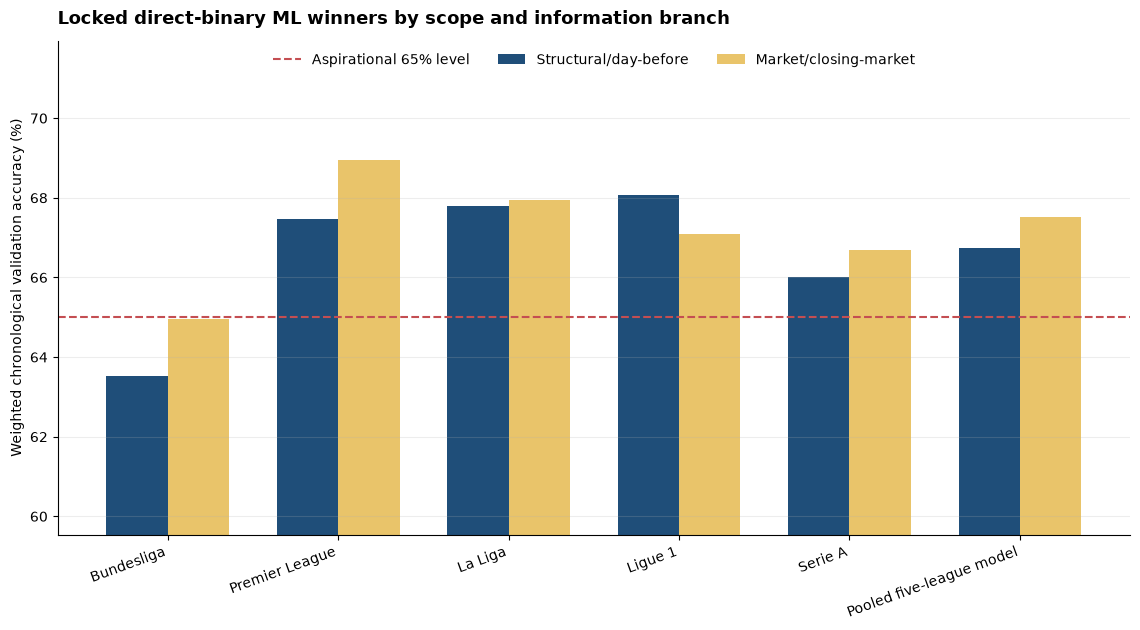

In [23]:
plot_winners = final_binary_winners.copy()
plot_winners["branch_label"] = plot_winners["branch"].map({"structural": "Structural", "market": "Market"})
pivot = plot_winners.pivot(index="scope", columns="branch_label", values="accuracy").reindex([name for _, name in SCOPES])

fig, ax = plt.subplots(figsize=(11.5, 6.4))
x = np.arange(len(pivot))
width = 0.36
ax.bar(x - width / 2, 100 * pivot["Structural"], width, label="Structural/day-before", color=COLOURS["structural"])
ax.bar(x + width / 2, 100 * pivot["Market"], width, label="Market/closing-market", color=COLOURS["market"])
ax.axhline(65, color=COLOURS["target"], linestyle="--", linewidth=1.5, label="Aspirational 65% level")
ax.set_xticks(x, pivot.index, rotation=20, ha="right")
ax.set_ylabel("Weighted chronological validation accuracy (%)")
ax.set_title("Locked direct-binary ML winners by scope and information branch", loc="left", pad=12)
ax.set_ylim(max(45, 100 * np.nanmin(pivot.to_numpy()) - 4), max(70, 100 * np.nanmax(pivot.to_numpy()) + 3))
ax.grid(axis="y")
ax.legend(frameon=False, ncol=3, loc="upper center")
fig.tight_layout()
plt.show()

The dashed line is an aspiration, not a selection constraint. A below-target branch remains locked if it is the honest direct-ML development winner. Market and structural results also have different information cut-offs and should not be described as operationally interchangeable.

## 9. Calibration and confusion matrices

A calibrated probability has the property

$$
P(Z=1\mid \widehat p\approx q)\approx q.
$$

Reliability curves divide out-of-fold probabilities into eight quantile bins. Each point compares the mean predicted probability with the observed home-win frequency. The diagonal is perfect calibration. The curves are diagnostic because each league has only two validation seasons.

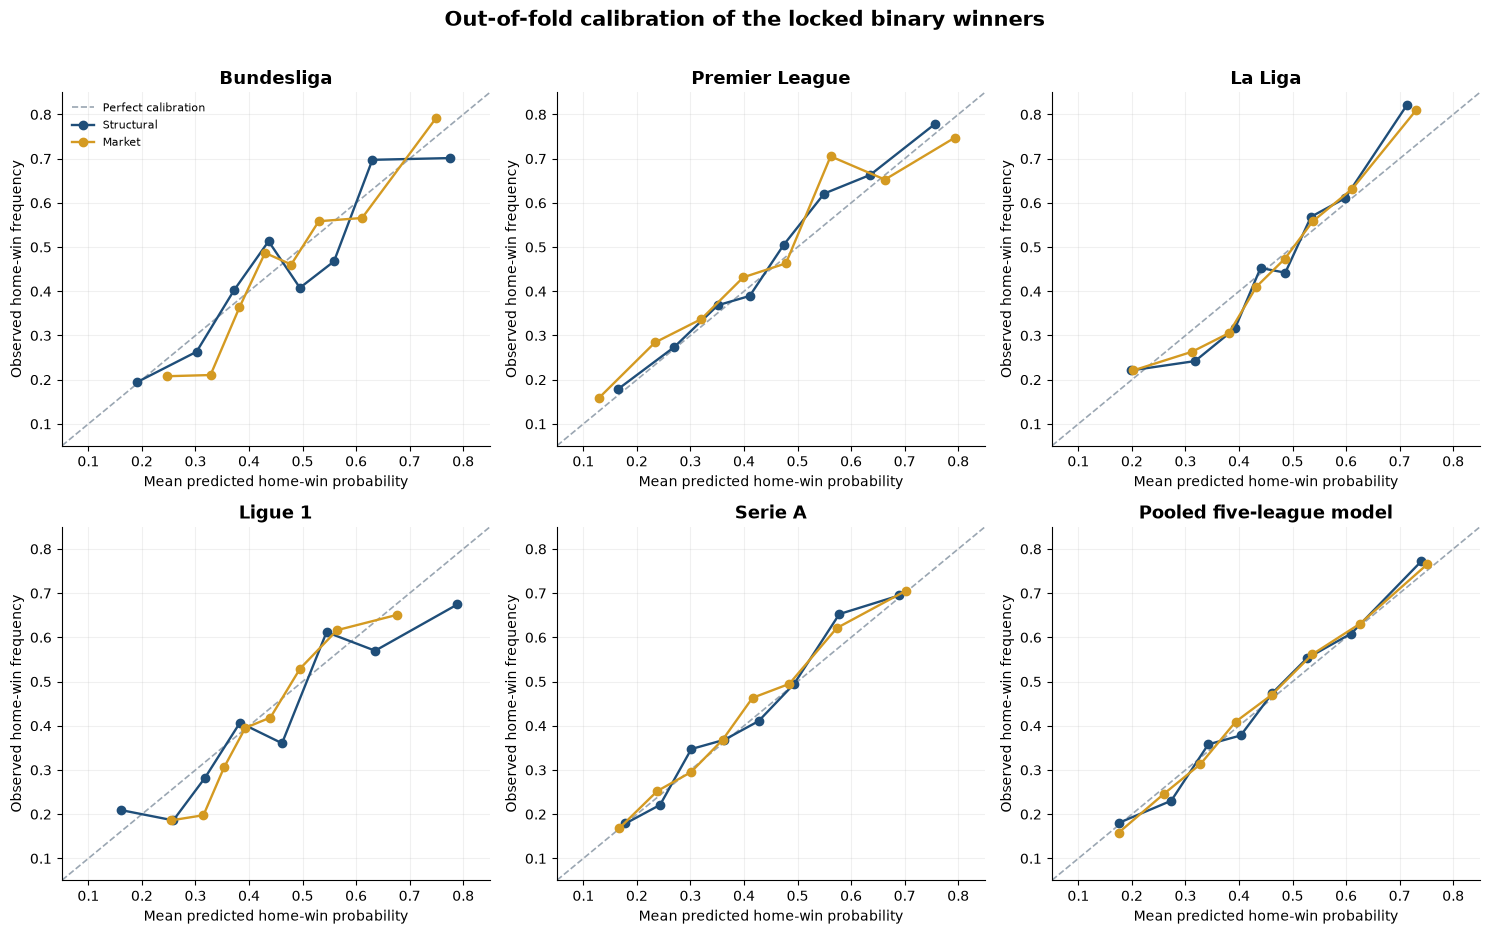

In [24]:
winner_prediction_parts = []
for winner in final_binary_winners.itertuples(index=False):
    selected = binary_oof_predictions.loc[
        binary_oof_predictions["scope_code"].eq(winner.scope_code)
        & binary_oof_predictions["branch"].eq(winner.branch)
        & binary_oof_predictions["method"].eq(winner.method)
    ].copy()
    selected["winner_scope"] = winner.scope
    selected["winner_branch"] = winner.branch
    winner_prediction_parts.append(selected)

final_winner_predictions = pd.concat(winner_prediction_parts, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9.2))
for ax, (scope_code, scope_name) in zip(axes.ravel(), SCOPES):
    ax.plot([0, 1], [0, 1], linestyle="--", color="#9AA6B2", linewidth=1.2, label="Perfect calibration")
    for branch, colour in [("structural", COLOURS["structural"]), ("market", "#D49A22")]:
        rows = final_winner_predictions.loc[
            final_winner_predictions["scope_code"].eq(scope_code)
            & final_winner_predictions["branch"].eq(branch)
        ]
        observed_rate, predicted_mean = calibration_curve(
            rows["observed"], rows["probability"], n_bins=8, strategy="quantile"
        )
        ax.plot(predicted_mean, observed_rate, marker="o", linewidth=1.7, color=colour, label=branch.title())
    ax.set_title(scope_name)
    ax.set_xlabel("Mean predicted home-win probability")
    ax.set_ylabel("Observed home-win frequency")
    ax.set_xlim(0.05, 0.85)
    ax.set_ylim(0.05, 0.85)
    ax.grid(alpha=0.18)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Out-of-fold calibration of the locked binary winners", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [25]:
confusion_rows = []
for keys, rows in final_winner_predictions.groupby(["scope", "branch", "method"], sort=True):
    scope, branch, method = keys
    metrics = evaluate_binary(rows["observed"], rows["probability"])
    confusion_rows.append({
        "scope": scope,
        "branch": branch,
        "winning_method": method,
        "home_non_win_correct_TN": metrics["true_negatives"],
        "home_non_win_called_home_win_FP": metrics["false_positives"],
        "home_win_called_non_win_FN": metrics["false_negatives"],
        "home_win_correct_TP": metrics["true_positives"],
        "matches": metrics["n_matches"],
        "combined_oof_accuracy": metrics["accuracy"],
    })

binary_confusion_table = pd.DataFrame(confusion_rows)
display(
    binary_confusion_table.style
    .format({"combined_oof_accuracy": "{:.2%}"})
    .hide(axis="index")
)

scope,branch,winning_method,home_non_win_correct_TN,home_non_win_called_home_win_FP,home_win_called_non_win_FN,home_win_correct_TP,matches,combined_oof_accuracy
Bundesliga,market,Direct binary ML,246,87,129,150,612,64.71%
Bundesliga,structural,Direct binary ML,232,101,122,157,612,63.56%
La Liga,market,Direct binary ML,307,104,145,204,760,67.24%
La Liga,structural,Direct binary ML,310,101,151,198,760,66.84%
Ligue 1,market,Direct binary ML,326,77,152,131,686,66.62%
Ligue 1,structural,Direct binary ML,302,101,123,160,686,67.35%
Pooled five-league model,market,Direct binary ML,1538,450,726,864,3578,67.13%
Pooled five-league model,structural,Direct binary ML,1535,453,749,841,3578,66.41%
Premier League,market,Direct binary ML,309,92,150,209,760,68.16%
Premier League,structural,Direct binary ML,308,93,157,202,760,67.11%


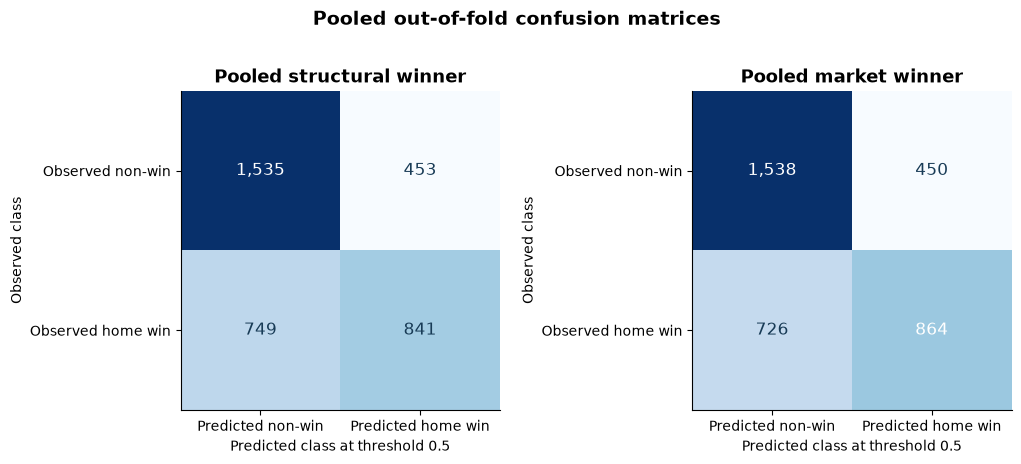

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, branch in zip(axes, ["structural", "market"]):
    rows = final_winner_predictions.loc[
        final_winner_predictions["scope_code"].eq("POOLED")
        & final_winner_predictions["branch"].eq(branch)
    ]
    metrics = evaluate_binary(rows["observed"], rows["probability"])
    matrix = np.array([
        [metrics["true_negatives"], metrics["false_positives"]],
        [metrics["false_negatives"], metrics["true_positives"]],
    ])
    image = ax.imshow(matrix, cmap="Blues")
    for row in range(2):
        for column in range(2):
            ax.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center", fontsize=12, color="white" if matrix[row, column] > matrix.max() * 0.55 else "#183B56")
    ax.set_xticks([0, 1], ["Predicted non-win", "Predicted home win"])
    ax.set_yticks([0, 1], ["Observed non-win", "Observed home win"])
    ax.set_title(f"Pooled {branch} winner")
    ax.set_xlabel("Predicted class at threshold 0.5")
    ax.set_ylabel("Observed class")
fig.suptitle("Pooled out-of-fold confusion matrices", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

The count table reports every scope and branch without stacking twelve heatmaps. The two pooled heatmaps provide a visual summary. False negatives are genuine home wins classified as home non-wins; false positives are home non-wins classified as home wins. Their balance explains differences between home-win recall and specificity.

## 10. Exact inputs to every locked direct-binary branch

Every locked branch is a direct binary classifier and therefore uses the binary-selected pre-match features. The table repeats the winning algorithm and hyperparameters beside every input so that a reader does not have to reconstruct the model from earlier outputs. Reference-method inputs remain documented in Sections 04 and 07 and do not enter this direct-ML registry.

In [27]:
final_multiclass_features = {}
for scope_code, scope_name in SCOPES:
    data = scope_data(scope_code)
    for branch in ["structural", "market"]:
        reference = MULTICLASS_REFERENCE[(scope_code, branch)]
        selection = select_training_features(data, scope_code, branch, "target_1x2")
        final_multiclass_features[(scope_code, branch)] = selection["feature_lists"][reference["subset"]]


input_rows = []
for winner in final_binary_winners.itertuples(index=False):
    if winner.method == "Direct binary ML":
        inputs = final_binary_features[(winner.scope_code, winner.branch)]
        roles = ["pre-match predictor"] * len(inputs)
        selection_roles = []
        audit = binary_selection_audit.loc[
            binary_selection_audit["scope"].eq(winner.scope)
            & binary_selection_audit["branch"].eq(winner.branch)
        ].set_index("feature")
        for feature in inputs:
            selection_roles.append(audit.loc[feature, "final_role"])
    elif winner.method == "Aggregated selected 1X2":
        inputs = final_multiclass_features[(winner.scope_code, winner.branch)]
        roles = ["pre-match predictor of the locked 1X2 model"] * len(inputs)
        selection_roles = ["selected in Notebook 03"] * len(inputs)
    elif winner.method == "Poisson P(X > Y)":
        inputs = ["date", "home_team", "away_team", "home/away status", "home_goals", "away_goals"]
        roles = [
            "recency-weight field", "team-effect identifier", "team-effect identifier",
            "activates mu_H", "historical response X", "historical response Y",
        ]
        selection_roles = ["Poisson specification"] * len(inputs)
    elif winner.method == "Direct market probability":
        inputs = ["market_prob_home"]
        roles = ["pre-match probability input"]
        selection_roles = ["direct market benchmark"]
    else:
        inputs = ["home_win in the training sample"]
        roles = ["training target frequency"]
        selection_roles = ["majority baseline"]

    for position, (feature, role, selection_role) in enumerate(zip(inputs, roles, selection_roles), start=1):
        source, calculation, cutoff = feature_metadata(feature) if feature in development.columns else ("Model definition", role, "Training data only")
        input_rows.append({
            "scope": winner.scope,
            "branch": winner.branch,
            "winning_method": winner.method,
            "algorithm": winner.algorithm,
            "hyperparameters": winner.hyperparameters,
            "development_accuracy": winner.accuracy,
            "position": position,
            "input": feature,
            "input_role": role,
            "selection_role": selection_role,
            "source": source,
            "calculation": calculation,
            "information_cutoff": cutoff,
        })

final_binary_input_registry = pd.DataFrame(input_rows)
display(
    final_binary_input_registry.style
    .format({"development_accuracy": "{:.2%}"})
    .hide(axis="index")
)

scope,branch,winning_method,algorithm,hyperparameters,development_accuracy,position,input,input_role,selection_role,source,calculation,information_cutoff
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,1,elo_diff_pre,pre-match predictor,mandatory core,Calculated from Understat results,Pre-match internal Elo state,Before current result update
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,2,clubelo_diff,pre-match predictor,mandatory core,ClubElo,"Dated rating level, contrast, expectation, or availability",Valid rating interval on match date
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,3,clubelo_available,pre-match predictor,mandatory core,ClubElo,"Dated rating level, contrast, expectation, or availability",Valid rating interval on match date
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,4,diff_sofifa_top11_overall,pre-match predictor,mandatory core,Public EA Sports player data,"Dated squad aggregate, contrast, age, or availability",Latest snapshot not after match date
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,5,sofifa_available,pre-match predictor,mandatory core,Public EA Sports player data,"Dated squad aggregate, contrast, age, or availability",Latest snapshot not after match date
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,6,diff_xg_diff_ewm_span_5,pre-match predictor,mandatory core,Understat history / project calculation,Shifted exponentially weighted mean,Earlier completed matches only
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,7,diff_points_mean_last_5,pre-match predictor,mandatory core,Understat history / project calculation,Shifted rolling mean of earlier matches,Earlier completed matches only
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,8,diff_rest_days,pre-match predictor,mandatory core,Understat fixture dates,"Rest days, short-rest flag, or contrast",Known before kick-off
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,9,home_promoted_or_returning,pre-match predictor,mandatory core,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only
Bundesliga,market,Direct binary ML,Binary logistic regression,{'C': 0.01},64.97%,10,away_promoted_or_returning,pre-match predictor,mandatory core,Understat history / project calculation,Pre-match history or context variable,Earlier completed matches only


The registry is the definitive answer to which variables enter every locked direct-binary branch. No market variable can enter a structural model, and `league_id` appears only in pooled machine-learning models.

## 11. Limitations and hand-off to the final test

The development comparison has several limitations:

- only two validation seasons are available, so differences below about half a percentage point are not treated as decisive;
- the same folds support selection among many algorithms, which can still produce development-selection optimism despite the compact grids;
- probability calibration is assessed on moderate league samples;
- accuracy depends on the fixed threshold 0.5 and on league-specific class prevalence;
- archived market odds provide a stronger information cutoff than the day-before structural branch;
- the Poisson model has interpretable score structure but restrictive independence and equidispersion assumptions;
- the aggregated 1X2 method inherits the draw-modelling strengths and weaknesses observed in Notebook 03.

The locked direct-ML winner, algorithm, hyperparameters, and input list for every scope and branch now pass to Notebook 06, accompanied by the reference methods. During the retrospective 2024/25 walk-forward test, models are refitted after each complete league round, or weekly when postponed matches disrupt the round. No feature selection, hyperparameter choice, ensemble composition, or probability threshold may be revised from the 2024/25 outcomes.

## 12. Conclusion

The binary task has been developed independently for all five leagues and the pooled comparison, with separate structural and market branches. All ten machine-learning algorithms were tuned after fold-safe feature selection. Their direct probabilities were compared with the locked 1X2 home probability, the independent-Poisson $P(X>Y)$ probability, the direct market probability where available, and the training-majority baseline.

The next notebook performs the only final out-of-time test on 2024/25. It begins by reporting the exact number of matches, first and last fixture dates, and prediction/refit blocks before evaluating the locked 1X2 and binary winners overall, by league, and through the season.